In [98]:
# Install Kaggle API
!pip install -q kaggle

In [99]:
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Error handling
if 'kaggle.json' not in uploaded:
    raise FileNotFoundError("kaggle.json not found! Please upload the file again.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [100]:
import os
import shutil

# Create .kaggle directory if not exists
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Move kaggle.json
shutil.move("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))

print("kaggle.json moved to ~/.kaggle/")

kaggle.json moved to ~/.kaggle/


In [101]:
# Set correct permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Permissions set to 600")

Permissions set to 600


In [102]:
# Download dataset from Kaggle
# Dataset: PlantVillage (Leaf Disease Classification)

!kaggle datasets download -d emmarex/plantdisease

print("Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded successfully!


In [103]:
import zipfile

zip_path = "plantdisease.zip"
extract_path = "plantdisease"

# Error handling
if not os.path.exists(zip_path):
    raise FileNotFoundError("Dataset zip file not found!")

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [104]:
import os

def display_directory_structure(start_path, max_depth=2):
    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, '').count(os.sep)
        if level > max_depth:
            continue
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = ' ' * 4 * (level + 1)
        for f in files[:5]:  # limit files display
            print(f"{sub_indent}{f}")

# Display structure
display_directory_structure("plantdisease")

plantdisease/
    plantvillage/
        PlantVillage/
    PlantVillage/
        Tomato_healthy/
            0f93b04b-73fc-4c5c-98d6-35842cafdd25___RS_HL 0278.JPG
            fc849a80-15fd-486d-bedc-0239e1278660___RS_HL 0494.JPG
            b4c862d2-74e7-44c7-be0e-226be86da648___RS_HL 9725.JPG
            b3e24070-34b9-4dcb-8c84-026affadfb4b___GH_HL Leaf 360.JPG
            83a8e340-30f9-4e2f-b825-a1078d5c63cf___RS_HL 0033.JPG
        Tomato__Tomato_mosaic_virus/
            da2bbe3c-5626-46d2-9640-2da89552f113___PSU_CG 2319.JPG
            f5d2043f-a274-431f-accc-1a3e1a7df172___PSU_CG 2400.JPG
            5c49d086-dc47-480e-b5b1-0b69bacb66bf___PSU_CG 2241.JPG
            0fefaaee-79e4-45a6-8606-5a4ab1ea43a2___PSU_CG 2398.JPG
            c16ac093-9b9b-4c37-b669-aa68f3cd55cf___PSU_CG 2270.JPG
        Tomato_Spider_mites_Two_spotted_spider_mite/
            9bedf503-beca-40b4-b1d1-6c12e96343f3___Com.G_SpM_FL 1481.JPG
            27b8928e-4fd2-4e84-bdb9-670a431477e0___Com.G_SpM_FL 8707.JPG

In [105]:
import os

# Base dataset path (from Step 1 extraction)
base_path = "plantdisease"

# Check contents
print("Folders inside dataset:")
print(os.listdir(base_path))

Folders inside dataset:
['plantvillage', 'PlantVillage']


In [106]:
import os

base_path = "plantdisease"

train_dir = os.path.join(base_path, "PlantVillage")
val_dir = None

print(f"Train Directory: {train_dir}")

Train Directory: plantdisease/PlantVillage


In [107]:
classes = [
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
]

print(classes[:5])

['Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Leaf_Mold', 'Pepper__bell___healthy']


In [108]:
cls = classes[0]
cls_path = os.path.join(train_dir, cls)

print("Class:", cls)
print("Files:", os.listdir(cls_path)[:5])

Class: Tomato_healthy
Files: ['0f93b04b-73fc-4c5c-98d6-35842cafdd25___RS_HL 0278.JPG', 'fc849a80-15fd-486d-bedc-0239e1278660___RS_HL 0494.JPG', 'b4c862d2-74e7-44c7-be0e-226be86da648___RS_HL 9725.JPG', 'b3e24070-34b9-4dcb-8c84-026affadfb4b___GH_HL Leaf 360.JPG', '83a8e340-30f9-4e2f-b825-a1078d5c63cf___RS_HL 0033.JPG']


In [109]:
from collections import defaultdict

image_count = defaultdict(int)

for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    files = os.listdir(cls_path)

    count = sum(
        1 for f in files
        if ".jpg" in f.lower() or ".jpeg" in f.lower() or ".png" in f.lower()
    )

    image_count[cls] = count

print("\nImages per class:\n")
for cls, count in list(image_count.items())[:10]:
    print(f"{cls}: {count}")


Images per class:

Tomato_healthy: 1591
Tomato__Tomato_mosaic_virus: 373
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato_Leaf_Mold: 952
Pepper__bell___healthy: 1478
Tomato_Septoria_leaf_spot: 1771
Tomato_Early_blight: 1000
Pepper__bell___Bacterial_spot: 997
Potato___Late_blight: 1000
Tomato__Target_Spot: 1404


In [110]:
# import os

# for root, dirs, files in os.walk("plantdisease"):
#     print("\nROOT:", root)
#     print("DIRS:", dirs)
#     print("FILES:", files[:5])

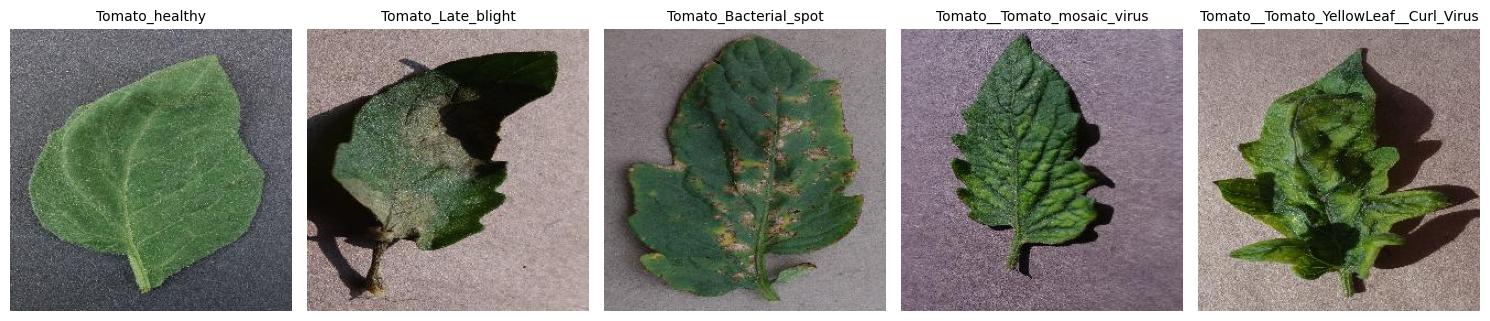

In [111]:
import matplotlib.pyplot as plt
import random
from PIL import Image

sample_classes = random.sample(classes, min(5, len(classes)))

plt.figure(figsize=(15, 8))

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(train_dir, cls)

    images = [
        f for f in os.listdir(cls_path)
        if ".jpg" in f.lower()
    ]

    img_path = os.path.join(cls_path, random.choice(images))
    img = Image.open(img_path)

    plt.subplot(1, len(sample_classes), i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [112]:
!pip install -q scikit-image opencv-python

import cv2
import numpy as np
from skimage.feature import hog, graycomatrix, graycoprops

In [113]:
def extract_features(image_path):
    try:
        # -------------------------------
        # 1. Load Image using OpenCV
        # -------------------------------
        image = cv2.imread(image_path)

        if image is None:
            # corrupted or unreadable file
            return None

        # Convert BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # -------------------------------
        # 2. Resize Image (128x128)
        # -------------------------------
        image = cv2.resize(image, (224, 224))

        # -------------------------------
        # 3. Grayscale Conversion
        # -------------------------------
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # -------------------------------
        # 4. HOG Features (Shape/Edges)
        # Captures leaf structure patterns
        # -------------------------------
        hog_features = hog(
          gray,
          orientations=16,
          pixels_per_cell=(8, 8),
          cells_per_block=(2, 2)
        )

        # -------------------------------
        # 5. Color Histogram (RGB)
        # Captures color distribution
        # -------------------------------
        hist_features = []

        for i in range(3):  # R, G, B channels
            hist = cv2.calcHist([image], [i], None, [32], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            hist_features.extend(hist)

        hist_features = np.array(hist_features)

        # -------------------------------
        # 6. GLCM Texture Features
        # Captures texture (disease patterns)
        # -------------------------------
        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, 'contrast')[0, 0]
        dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        glcm_features = np.array([
            contrast,
            dissimilarity,
            homogeneity,
            energy,
            correlation
        ])

        # -------------------------------
        # 7. Combine All Features
        # -------------------------------
        combined_features = np.hstack((
            hog_features,
            hist_features,
            glcm_features
        ))

        return combined_features

    except Exception as e:
        # handle any unexpected errors safely
        return None

In [114]:
# pick one sample image
sample_class = classes[0]
sample_path = os.path.join(train_dir, sample_class)

sample_image = os.listdir(sample_path)[0]
image_path = os.path.join(sample_path, sample_image)

features = extract_features(image_path)

print("Feature vector length:", len(features))

Feature vector length: 46757


In [115]:
import numpy as np
import os

X_train, y_train = [], []
X_val, y_val = [], []

In [116]:
# Limits (you can tweak later)
train_limit = 250   # per class
val_limit = 120      # per class

In [117]:
import random

print("Starting dataset creation...\n")

for label, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Skip hidden/system folders
    if cls.startswith('.'):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if ".jpg" in f.lower() or ".png" in f.lower() or ".jpeg" in f.lower()
    ]

    # Shuffle images for random split
    random.shuffle(images)

    train_count = 0
    val_count = 0

    print(f"Processing class: {cls}")

    for img_name in images:
        img_path = os.path.join(cls_path, img_name)

        features = extract_features(img_path)

        # Skip corrupted images
        if features is None:
            continue

        # Fill training set
        if train_count < train_limit:
            X_train.append(features)
            y_train.append(label)
            train_count += 1

        # Fill validation set
        elif val_count < val_limit:
            X_val.append(features)
            y_val.append(label)
            val_count += 1

        # Stop when both limits reached
        if train_count >= train_limit and val_count >= val_limit:
            break

    print(f" → Train: {train_count}, Val: {val_count}\n")

Starting dataset creation...

Processing class: Tomato_healthy
 → Train: 250, Val: 120

Processing class: Tomato__Tomato_mosaic_virus
 → Train: 250, Val: 120

Processing class: Tomato_Spider_mites_Two_spotted_spider_mite
 → Train: 250, Val: 120

Processing class: Tomato_Leaf_Mold
 → Train: 250, Val: 120

Processing class: Pepper__bell___healthy
 → Train: 250, Val: 120

Processing class: Tomato_Septoria_leaf_spot
 → Train: 250, Val: 120

Processing class: Tomato_Early_blight
 → Train: 250, Val: 120

Processing class: Pepper__bell___Bacterial_spot
 → Train: 250, Val: 120

Processing class: Potato___Late_blight
 → Train: 250, Val: 120

Processing class: Tomato__Target_Spot
 → Train: 250, Val: 120

Processing class: Tomato_Late_blight
 → Train: 250, Val: 120

Processing class: Potato___Early_blight
 → Train: 250, Val: 120

Processing class: Tomato_Bacterial_spot
 → Train: 250, Val: 120

Processing class: Potato___healthy
 → Train: 152, Val: 0

Processing class: Tomato__Tomato_YellowLeaf__C

In [118]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

In [119]:
print("Dataset Summary:\n")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Dataset Summary:

X_train shape: (3652, 46757)
y_train shape: (3652,)
X_val shape: (1680, 46757)
y_val shape: (1680,)


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [121]:
# Learn mean and standard deviation from training data
X_train_scaled = scaler.fit_transform(X_train)

# Use SAME scaling (do not fit again)
X_val_scaled = scaler.transform(X_val)

In [122]:
print("Scaled Data Shapes:\n")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

Scaled Data Shapes:

X_train_scaled: (3652, 46757)
X_val_scaled: (1680, 46757)


In [123]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [124]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

X_train_final = normalizer.fit_transform(X_train_scaled)
X_val_final = normalizer.transform(X_val_scaled)

In [125]:
# print("Training SVM...")

# svm_model = SVC(kernel='rbf', C=10, gamma='scale')

# svm_model.fit(X_train_scaled, y_train)

# print("SVM training completed.")

In [126]:
# y_pred_svm = svm_model.predict(X_val_scaled)

# svm_accuracy = accuracy_score(y_val, y_pred_svm)

# print(f"SVM Accuracy: {svm_accuracy:.4f}")

In [127]:
# print("\nTraining Random Forest...")

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_scaled, y_train)

# print("Random Forest training completed.")

In [128]:
# y_pred_rf = rf_model.predict(X_val_scaled)

# rf_accuracy = accuracy_score(y_val, y_pred_rf)

# print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

In [129]:
# from sklearn.model_selection import GridSearchCV

# print("Tuning SVM...")

# param_grid = {
#     'C': [1, 10, 50],
#     'gamma': ['scale', 0.01, 0.001],
#     'kernel': ['rbf']
# }

# grid_svm = GridSearchCV(
#     SVC(),
#     param_grid,
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# grid_svm.fit(X_train_scaled, y_train)

# best_svm = grid_svm.best_estimator_

# print("Best SVM Params:", grid_svm.best_params_)

In [130]:
# y_pred_svm = best_svm.predict(X_val_scaled)

# from sklearn.metrics import accuracy_score
# print("Tuned SVM Accuracy:", accuracy_score(y_val, y_pred_svm))

In [131]:
# print("\nTraining Improved Random Forest...")

# rf_model = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=None,
#     min_samples_split=2,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_scaled, y_train)

# y_pred_rf = rf_model.predict(X_val_scaled)

# print("Improved RF Accuracy:", accuracy_score(y_val, y_pred_rf))

In [132]:
# from sklearn.decomposition import PCA

# print("Applying PCA...")

# pca = PCA(n_components=150)  # keep 95% variance

# X_train_pca = pca.fit_transform(X_train_scaled)
# X_val_pca = pca.transform(X_val_scaled)

# print("Original shape:", X_train_scaled.shape)
# print("Reduced shape:", X_train_pca.shape)

In [133]:
# svm_model = SVC(kernel='rbf', C=10, gamma='scale')

# svm_model.fit(X_train_pca, y_train)
# #
# y_pred = svm_model.predict(X_val_pca)

# from sklearn.metrics import accuracy_score
# print("SVM + PCA Accuracy:", accuracy_score(y_val, y_pred))

In [134]:
# svm_model = SVC(kernel='rbf', C=50, gamma=0.001)

# svm_model.fit(X_train_final, y_train)

# y_pred = svm_model.predict(X_val_final)

# from sklearn.metrics import accuracy_score
# print("SVM Accuracy (Scaled + Normalized):", accuracy_score(y_val, y_pred))

In [135]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [136]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # standard size for CNN
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [137]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes[:5])

Total images: 20638
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [138]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

In [139]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [140]:
model = models.resnet18(pretrained=True)

# Freeze feature extractor
for param in model.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [141]:
num_classes = len(dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [142]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [144]:
# ==============================
# 1. Install & Imports
# ==============================
!pip install -q tqdm scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import os

# ==============================
# 2. Device (GPU / CPU)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==============================
# 3. Transforms
# ==============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==============================
# 4. Load Dataset
# ==============================
train_dir = "plantdisease/PlantVillage"

dataset = datasets.ImageFolder(root=train_dir, transform=transform)

print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

# ==============================
# 5. Train / Validation Split
# ==============================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

# ==============================
# 6. DataLoaders
# ==============================
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

# ==============================
# 7. Load Pretrained Model
# ==============================
model = models.resnet18(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# ==============================
# 8. Loss & Optimizer
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ==============================
# 9. Training Loop
# ==============================
epochs = 5

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    train_preds = []
    train_labels = []

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    print(f"Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")

    # -------- VALIDATION --------
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_precision = precision_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_recall = recall_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_f1 = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

    print(f"Val Acc: {val_acc:.4f}")
    print(f"Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")

Using device: cpu
Total Images: 20638
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Epoch 1/5


Training: 100%|██████████| 516/516 [16:56<00:00,  1.97s/it]


Train Loss: 0.8281 | Train Acc: 0.7818


Validation: 100%|██████████| 129/129 [03:52<00:00,  1.81s/it]


Val Acc: 0.9048
Precision: 0.9045 | Recall: 0.9048 | F1: 0.9034

Epoch 2/5


...

Val Acc: 0.9317
Precision: 0.9329 | Recall: 0.9317 | F1: 0.9314

Epoch 5/5


Training: 100%|██████████| 516/516 [16:23<00:00,  1.91s/it]


Train Loss: 0.2407 | Train Acc: 0.9274


Validation: 100%|██████████| 129/129 [03:54<00:00,  1.82s/it]

Val Acc: 0.9310
Precision: 0.9312 | Recall: 0.9310 | F1: 0.9301


In [ ]:
# model.eval()
# correct = 0
# total = 0

# with torch.no_grad():
#     for images, labels in val_loader:
#         images, labels = images.to(device), labels.to(device)

#         outputs = model(images)
#         _, predicted = torch.max(outputs, 1)

#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

# print("Validation Accuracy:", correct / total)

In [145]:
class_names = dataset.classes

import matplotlib.pyplot as plt
from PIL import Image

def predict_image(model, image_path, transform, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    predicted_class = class_names[pred.item()]

    return image, predicted_class


# pick a random image from dataset
img_path, true_label = dataset.samples[0]

image, prediction = predict_image(model, img_path, transform, class_names)

plt.imshow(image)
plt.title(f"Predicted: {prediction}")
plt.axis('off')
plt.show()


import random

plt.figure(figsize=(15, 10))

indices = random.sample(range(len(dataset)), 6)

for i, idx in enumerate(indices):
    img_path, true_label = dataset.samples[idx]

    image, prediction = predict_image(model, img_path, transform, class_names)

    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(f"P: {prediction}\nT: {class_names[true_label]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [146]:
import torch.nn.functional as F

def predict_image(model, image_path, transform, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)

    predicted_class = class_names[pred.item()]

    return image, predicted_class, confidence.item()

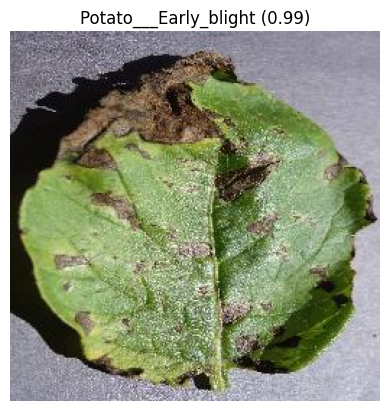

In [147]:
image, prediction, confidence = predict_image(model, img_path, transform, class_names)

plt.imshow(image)
plt.title(f"{prediction} ({confidence:.2f})")
plt.axis('off')
plt.show()